### Agent-based Choice Modeling Based on (S-shaped) Learning 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from numpy import log as ln
import osmnx as ox
import math
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy import optimize

import ExMAS.utils
from ExMAS.utils import inData
from src import functions as fncs
import random

import seaborn as sns

In [2]:
OTP_API = "http://localhost:8080/otp/routers/default/plan"
params = ExMAS.utils.get_config('data/configs/default_SUM.json')

In [3]:
# Load graph
inData = ExMAS.utils.load_G(inData, params, stats=True)

In [4]:
# Read files with data: Krakow zones and their centroids
gdf_zones = gpd.read_file('data/krk_zones.geojson')
gdf_centroid = gpd.read_file('data/krk_centroid.geojson')

<AxesSubplot:>

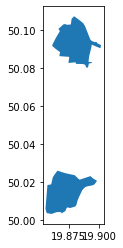

In [5]:
# Read SUM areas: Bronowice and Skotniki
gdf_areas = gpd.read_file('data/sum_areas/sum_areas_B+S.shp')
gdf_areas = gdf_areas.rename(columns={"nazwa": "name"})
gdf_areas['name'] = gdf_areas['name'].replace('Bronowice Wielkie', 'Bronowice')
# transform coordinate system to EPSG:4326
gdf_areas = gdf_areas.to_crs(4326) 
gdf_areas.plot()

In [6]:
gdf_areas

,name,geometry
0,Bronowice,"POLYGON ((19.87805 50.08284, 19.87469 50.08260..."
1,Skotniki,"POLYGON ((19.88842 50.01723, 19.88734 50.01662..."


In [7]:
# Read ODMs and calculate the "probabilities" for destinations
od = pd.read_excel('data/krk_ODM.xlsx', 'AM_peak_PuT', skiprows=[1, 2])
od.rename(columns = {'464 x 464' : 'zone_NO', 'Unnamed: 2': 'sum'}, inplace = True)
od.drop(od.filter(regex="Unname"), axis=1, inplace=True)
od.reset_index(drop=True, inplace=True)
od[0:] = od[:].astype(float)
od['zone_NO'] = od['zone_NO'].astype(int)
# filter OD zone number to match city zones and recalculate sum for origins
od = od.loc[od['zone_NO'].isin(gdf_zones['NO']), ['zone_NO', 'sum'] + gdf_zones['NO'].to_list()]
od['sum'] = od.loc[:, 1:].sum(axis=1)
# calculate destination "probability" for each origin point
od_probs = pd.concat([od['zone_NO'], 
            od.loc[:, 'sum':].astype('float64').divide(od.loc[:, 'sum'].astype('float64'), axis=0)], axis=1)

In [8]:
# Read demographic of the city, clean data
df_demo = pd.read_csv('data/krk_demographic.csv', index_col=0)
df_demo = df_demo.rename(columns={"adr_pelny": "address", "ogolem": "total" })
# assign new coordinates for addresses from outside the city zone
filter = ['STAREGO DĘBU' in i for i in df_demo['address']]
df_demo.loc[filter, 'x'], df_demo.loc[filter, 'y'] = 19.872702, 50.100578
# assign zone number to each address point
df_demo['zone_NO'] = df_demo.apply(lambda row: 
                                   fncs.find_containing_polygon(Point(row['x'], row['y']), gdf_zones), axis=1)
# remove the trips with nan zone
df_demo.dropna(subset='zone_NO', inplace=True, ignore_index=True)

In [9]:
# Chosen hub locations for each area
hubs = {"Bronowice": (19.88192, 50.08179), "Skotniki": (19.88948, 50.01844)}
# hubs = {"Bronowice": (19.88192, 50.08179), "Skotniki": (19.88948, 50.01844), "Swoszowice": (19.95042, 50.01356)}

In [ ]:
def simulate_learning(gdf_areas, df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=100, ASC=2.15, results_period=0) -> dict:
    
    results = {} # main dictionary to store all the results
    
    for _, area in gdf_areas.iterrows(): 
        key = area["name"]
        hub = hubs[key]
        dfres = pd.DataFrame()
        df_kpi_res = pd.DataFrame()
        ascs = [] # if ASC=None, store ASC for each sample of each area
        df_F_Us = pd.DataFrame() # to store avg times expected for each replication
        signals = []  # to collect signal_u values

        s_res = [] # to store dataframes with learning agents (df_sum_sh)
            
        for repl in range(N):

            df_kpis = pd.DataFrame()
            area_reqs = fncs.define_demand(area, df_demo, gdf_centroid, od, od_probs, params)
            df = area_reqs[key].copy() # df with {O, D, Treq} for the area
            print(repl + 1, "run simulations for area", key, ": sample size ", df.shape[0])

            # OPTION I: Utility for PT OD
            u_pt_od = df.copy()
            u_pt_od = fncs.run_OTP(u_pt_od, OTP_API) # define PT routes for each traveller
            fncs.PT_utility(u_pt_od, params)  
            
            df = df.loc[u_pt_od.index, :] # select requests with successful OD trips 
            df.reset_index(drop=True, inplace=True)

            # OPTION II: Utility for SUM (ExMAS OH + PT HD)
            df_sum = df.copy()
            
            # Utility for SINGLE TRIPS OH
            df_sum['origin'] = df_sum.apply(lambda row: ox.nearest_nodes(inData.G, row['origin_x'], row['origin_y']), axis=1)
            df_sum['destination'] = ox.nearest_nodes(inData.G, hub[0], hub[1])
            df_sum['dist'] = df_sum.apply(lambda request: inData.skim.loc[request.origin, request.destination], axis=1)
            
            # ttrav!!
            df_sum['ttrav'] = df_sum['dist'].apply(lambda request: request / params.avg_speed)
            # lower initial U
            # df_sum['ttrav'] = 2 * df_sum['dist'].apply(lambda request: request / params.avg_speed)
            df_sum['tarr'] = df_sum.treq + df_sum.apply(lambda df_sum: pd.Timedelta(df_sum.ttrav, 's').floor('s'), axis=1)
            
            # vars for learning
            df_sum['F_U'] = params.min_U # it's pre_F_U
            df_sum['PT_U'] = 0.5  # a constant

            df_F_Us['0'] = df_sum['F_U'] # initial value of F_U

            # Utility for PT HD
            u_pt_hd = df_sum[['origin_x', 'origin_y', 'destination_x', 'destination_y', 'tarr']]
            # change origin x, y to hub coordinates
            u_pt_hd['origin_x'], u_pt_hd['origin_y'] = hub
            # treq for PT_HD = treq + ttrav + transfertime
            u_pt_hd['treq'] = pd.to_datetime(u_pt_hd.tarr) + pd.Timedelta(params.transfertime, unit='s')
            u_pt_hd = fncs.run_OTP(u_pt_hd, OTP_API)
            fncs.PT_utility(u_pt_hd, params)

            u_pt_od = u_pt_od.loc[u_pt_hd.index, :] # drop rows with unsuccessful HD trips 
            u_pt_od.reset_index(drop=True, inplace=True)
            df_sum = df_sum.loc[u_pt_hd.index, :] 
            df_sum.reset_index(drop=True, inplace=True)
            u_pt_hd.reset_index(drop=True, inplace=True)
            
            df_sum['u_PT_OD'] = u_pt_od.u_PT # utility for PT OD
            df_sum['u_PT_HD'] = u_pt_hd.u_PT # utility for PT HD
            # Utility for SUM OD
            df_sum['u_SUM_OD'] = df_sum.apply(lambda request: request['ttrav'] * params.VoT * params.WtS + \
                                                request['dist'] * params.price / 1000, axis=1) + u_pt_hd.u_PT + ASC if ASC else \
                                 df_sum.apply(lambda request: request['ttrav'] * params.VoT * params.WtS + \
                                                request['dist'] * params.price / 1000, axis=1) + u_pt_hd.u_PT
            # probability of using SUM for each traveler in a single trip
            df_sum['F_P'] = df_sum.apply(lambda row: math.exp(-row.u_SUM_OD) / \
                                          (math.exp(-row.u_SUM_OD) + math.exp(-row.u_PT_OD)), axis=1)
            print("F_P ",  df_sum.F_P.mean())
            
            # ASC calculation
            if not ASC:
                degree = 1
                ascs.append(optimize.fsolve(lambda x: fncs.calc_E_p_sum(df_sum, x) - params.expected_prob, 0)[0])
                print(repl, "ASC ", key, ascs[repl])
            
            df_sum['nTrips'] = 0 # number of shared trips
            
            if degree > 1:
                for i in range(1, max_iter + 1):

                    # varying lambda affects sharability graph in ExMAS
                    params.shared_discount = 0.0 if i < 50 else 0.3
                    print('iteration ', i, ' for', key)
                    
                    sum_demand = df_sum[df_sum.apply(lambda row: random.random() < row['F_P'], axis=1)] # mode choice
                    print('sum_demand sample', sum_demand.shape[0])
                    
                    df_sum_sh = sum_demand[['origin_x', 'origin_y', 'destination_x', 'destination_y', 'treq', 'origin', 'destination', 'dist', 'ttrav', 'u_PT_OD', 'nTrips', 'F_U', 'PT_U']]
                    df_sum_sh['nTrips'] = df_sum_sh['nTrips'] + 1

                    if df_sum_sh.shape[0] == 0: # on some iterations there are NO travelers if start with 10% 
                        continue

                    fncs.run_ExMAS(df_sum_sh, inData, params, hub, degree)
                    
                    # sort data after ExMAS shuffled trips to assign ttrav_sh to SUM travelers
                    inData_reqs_sorted = inData.sblts.requests.sort_values('index') 
                    inData_reqs_sorted.set_index('index', inplace=True)
                    inData_reqs_sorted = inData_reqs_sorted.rename_axis(None)
                    df_sum_sh['ttrav_sh'] = inData_reqs_sorted['ttrav_sh']
                    df_sum_sh['tarr'] = df_sum_sh.treq + df_sum_sh.apply(
                        lambda req: pd.Timedelta(req.ttrav_sh, 's').floor('s'), axis=1)
                
                    # assign indexes of shared trips to column 'indexes_sum' and RESET INDEX to calculate OTP
                    df_sum_sh.insert(0, 'indexes_sum', df_sum_sh.index)
                    df_sum_sh = df_sum_sh.reset_index(drop=True)

                    # Utility for PT HD
                    u_pt_hd = df_sum_sh[['indexes_sum', 'origin_x', 'origin_y', 'destination_x', 'destination_y', 'tarr']]
                    # change origin x, y to hub coordinates
                    u_pt_hd['origin_x'], u_pt_hd['origin_y'] = hub
                    # treq for PT_HD = treq + ttrav_sh = tarr
                    u_pt_hd['treq'] = pd.to_datetime(u_pt_hd.tarr)
                    u_pt_hd = fncs.run_OTP(u_pt_hd, OTP_API)
                    fncs.PT_utility(u_pt_hd, params)

                    # drop rows with unsuccessful HD trips only for df_sum_sh (as u_PT_OD is the same as for the single rides)
                    df_sum_sh = df_sum_sh.loc[u_pt_hd.index, :] 
                    df_sum_sh.reset_index(drop=True, inplace=True)
                    u_pt_hd.reset_index(drop=True, inplace=True)
                    
                    # Utility F OH <- use shared_discount = 0.3
                    df_sum_sh['u_F'] = df_sum_sh.apply(lambda request: request['ttrav'] * params.VoT * params.WtS + 
                                            request['dist'] * params.price * 0.7 / 1000, axis=1)
                                            
                    # df_sum['u_PT_OD'] doesn't change for SUM demand
                    df_sum_sh['u_PT_HD'] = u_pt_hd.u_PT
                    df_sum_sh['u_SUM_OD'] = df_sum_sh.u_F + u_pt_hd.u_PT + ASC
                    df_sum_sh['F_P'] = df_sum_sh.apply(lambda row: math.exp(-row.u_SUM_OD) / \
                                            (math.exp(-row.u_SUM_OD) + math.exp(-row.u_PT_OD)), axis=1)
                    
                    # --------------------------------------------------
                    # SIGMOID
                    # df_sum_sh['pre_F_U'] = min_U if iteration == 1 else df_sum_sh[i - 1].F_U # <- no needed
                    df_sum_sh['signal_u'] = df_sum_sh.apply(lambda row: (row.u_PT_OD - row.u_SUM_OD) / row.u_PT_OD, axis=1)
                    df_sum_sh['F_U'] = df_sum_sh.apply(lambda row: min((1-1e-2), 
                            max(1 / (1 + math.exp(ln(1 / row.F_U - 1) + params.learning_d * row.signal_u)), 1e-2)), axis=1)

                    df_sum_sh['F_P'] = df_sum_sh.apply(lambda row: (math.exp(params.mu * row.F_U)) / 
                                                       (math.exp(params.mu * row.F_U) + math.exp(params.mu * row.PT_U)), axis=1)
                    signals.extend(df_sum_sh['signal_u'].tolist())

                    # --------------------------------------------------
                    df_F_Us.loc[df_sum_sh['indexes_sum'], [f'i_{i}']] = df_sum_sh[['F_U']].values
                    
                    df_pt = df_sum.copy() # df to store PT travelers
                    df_pt = df_pt.drop(index=df_sum_sh['indexes_sum'])

                    # Update values for agents chosen for SUM in the main table with the whole sample
                    df_sum.loc[df_sum_sh['indexes_sum'], ['nTrips']] = df_sum_sh[['nTrips']].values
                    df_sum.loc[df_sum_sh['indexes_sum'], ['F_P']] = df_sum_sh[['F_P']].values
                    df_sum.loc[df_sum_sh['indexes_sum'], ['F_U']] = df_sum_sh[['F_U']].values

                    s_res.append(df_sum_sh)

            df_means = pd.DataFrame([[u_pt_od.waitingTime.mean(), u_pt_hd.waitingTime.mean(), u_pt_od.u_PT.mean(),
                                        u_pt_hd.u_PT.mean(), df_sum.u_SUM_OD.mean(), df_sum.F_P.mean()]], 
                                        columns=['tw_PT_OD', 'tw_PT_HD', 'u_PT_OD', 'u_PT_HD', 'u_SUM_OD', 'p_SUM'])
            dfres = pd.concat([dfres, df_means], ignore_index=True)
            df_kpi_res = pd.concat([df_kpi_res, df_kpis], axis=1)
            
            print()    
        print("===============================================================")
        
        results[key] = {'avg_sim_res': dfres, 'sum_res': df_sum, 'kpis_res': df_kpi_res, 
                        'asc_res': ascs, 's_res': s_res, 'df_fus': df_F_Us, 'signals': signals}
    return results

In [ ]:
# calc ASC for E(p_F ~ 10%)
params.learning_d = 1.0 
params.mu = 5
params.min_U = 0.01

params.expected_prob = 0.1

res_asc = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=30, max_iter=0, ASC=None, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.488489394264764
0 ASC  Skotniki 11.650641240755382

2 run simulations for area Skotniki : sample size  155
F_P  0.5292857120468553
1 ASC  Skotniki 3.7553221729378343

3 run simulations for area Skotniki : sample size  155
F_P  0.5438195263239873
2 ASC  Skotniki 9.830097307937814

4 run simulations for area Skotniki : sample size  155
F_P  0.4926628130469904
3 ASC  Skotniki 4.190041167850959

5 run simulations for area Skotniki : sample size  155
F_P  0.5240722113328478
4 ASC  Skotniki 11.049884022665754

6 run simulations for area Skotniki : sample size  155
F_P  0.5282535804370991
5 ASC  Skotniki 3.9672032560089177

7 run simulations for area Skotniki : sample size  155
F_P  0.483253030913404
6 ASC  Skotniki 3.753961408559983

8 run simulations for area Skotniki : sample size  155
F_P  0.5243859497788756
7 ASC  Skotniki 11.242735333825038

9 run simulations for area Skotniki : sample size  155
F_P  0.5623915821066534
8 ASC 

In [17]:
# ASC for E(p_SUM) ~ 10%
print(sum(res_asc["Skotniki"]["asc_res"]) / len(res_asc["Skotniki"]["asc_res"]))

5.804076980032845


#### TEST: E(p_F) ~ 10% <-- on some iteration it may cause sum_demand sample = 0 and error while running ExMAS
<br>params.shared_discount = 0.0 if i < 50 else 0.3
<br>df_sum_sh['u_F'] = df_sum_sh.apply(lambda request: request['ttrav'] * params.VoT * params.WtS + request['dist'] * params.price * 0.7 / 1000, axis=1)

In [ ]:
# SET UP shared_discount = 0.0 if i < 50 else 0.3
params.learning_d = 1.5 # learning rate
params.mu = 5
params.min_U = 0.01
params.shared_discount = 0

res_400_0 = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=400, ASC=5.8, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.030885464810344383
iteration  1  for Skotniki
sum_demand sample 4
iteration  2  for Skotniki
sum_demand sample 4
iteration  3  for Skotniki
sum_demand sample 8
iteration  4  for Skotniki
sum_demand sample 5
iteration  5  for Skotniki
sum_demand sample 3
iteration  6  for Skotniki
sum_demand sample 4
iteration  7  for Skotniki
sum_demand sample 6
iteration  8  for Skotniki
sum_demand sample 5
iteration  9  for Skotniki
sum_demand sample 4
iteration  10  for Skotniki
sum_demand sample 5
iteration  11  for Skotniki
sum_demand sample 1
iteration  12  for Skotniki
sum_demand sample 3
iteration  13  for Skotniki
sum_demand sample 4
iteration  14  for Skotniki
sum_demand sample 5
iteration  15  for Skotniki
sum_demand sample 3
iteration  16  for Skotniki
sum_demand sample 2
iteration  17  for Skotniki
sum_demand sample 3
iteration  18  for Skotniki
sum_demand sample 2
iteration  19  for Skotniki
sum_demand sample 1
iteration  20  f

In [ ]:
res_400_0["Skotniki"]["s_res"][399]

,indexes_sum,origin_x,origin_y,destination_x,destination_y,treq,origin,destination,dist,ttrav,...,nTrips,F_U,PT_U,ttrav_sh,tarr,u_F,u_PT_HD,u_SUM_OD,F_P,signal_u
0,0,19.866615,50.015050,19.915984,50.031339,2024-03-28 07:45:11,1349565614,1989392511,1962,327.000000,...,215,0.99,0.5,327,2024-03-28 07:50:38,3.04110,4.720437,13.561537,0.920561,-0.265495
1,1,19.873247,50.015163,19.903453,49.986253,2024-03-28 07:47:57,967785623,1989392511,1502,250.333333,...,225,0.99,0.5,250,2024-03-28 07:52:07,2.32810,12.242337,20.370437,0.920561,-0.166053
2,2,19.883469,50.013328,19.941533,50.041045,2024-03-28 07:59:16,6221675164,1989392511,744,124.000000,...,301,0.99,0.5,124,2024-03-28 08:01:20,1.15320,12.309359,19.262559,0.920561,-0.152785
3,6,19.874652,50.018359,19.934131,50.034490,2024-03-28 07:54:24,8644189126,1989392511,1519,253.166667,...,280,0.99,0.5,253,2024-03-28 07:58:37,2.35445,8.281882,16.436332,0.920561,-0.364252
4,7,19.872567,50.013225,19.930973,50.026588,2024-03-28 08:05:14,967785571,1989392511,1820,303.333333,...,34,0.99,0.5,303,2024-03-28 08:10:17,2.82100,6.673324,15.294324,0.920561,-0.480161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,127,19.876580,50.009821,19.907826,49.996216,2024-03-28 08:05:05,497388653,1989392511,1812,302.000000,...,38,0.99,0.5,302,2024-03-28 08:10:07,2.80860,11.519653,20.128253,0.920561,-0.420782
60,128,19.884263,50.014585,19.919219,50.065863,2024-03-28 08:14:30,3005106299,1989392511,1132,188.666667,...,61,0.99,0.5,188,2024-03-28 08:17:38,1.75460,12.398443,19.953043,0.920561,-1.276641
61,132,19.875612,50.012636,19.927274,50.057716,2024-03-28 07:46:59,295825429,1989392511,1704,284.000000,...,308,0.99,0.5,284,2024-03-28 07:51:43,2.64120,15.55303,23.99423,0.920561,-0.781444
62,135,19.872504,50.018573,19.947150,50.069255,2024-03-28 07:59:29,8644189124,1989392511,1659,276.500000,...,270,0.99,0.5,276,2024-03-28 08:04:05,2.57145,18.568366,26.939816,0.920561,-0.617957


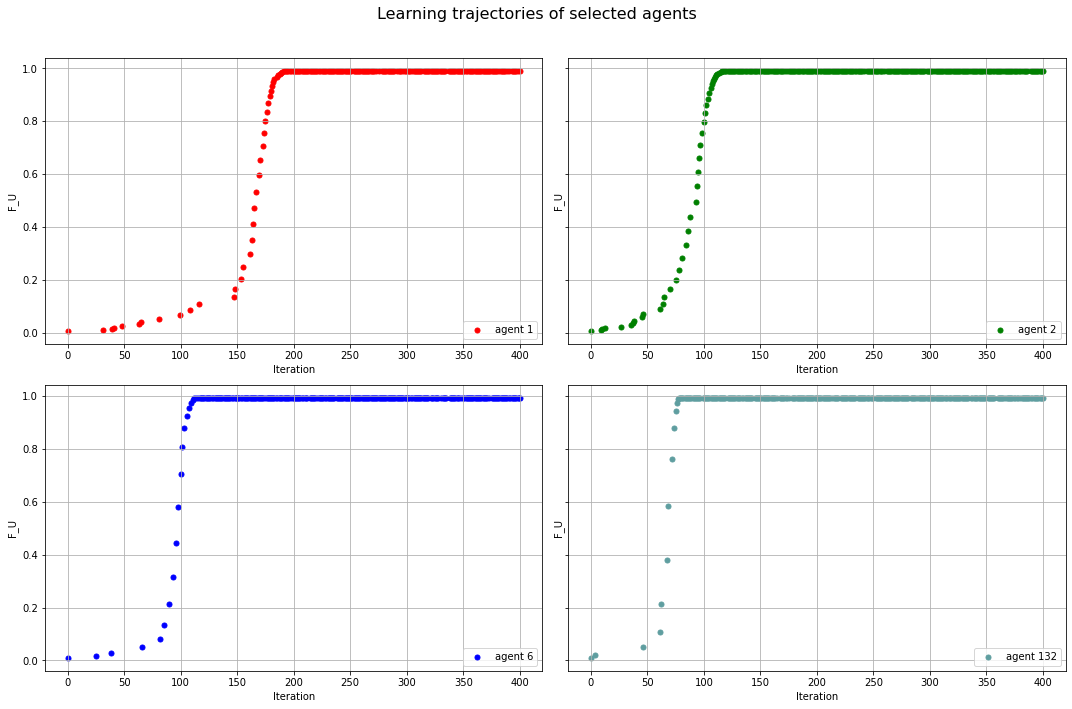

In [ ]:
# 400 iterations
ns = [1, 2, 6, 132]
colors = ['red', 'green', 'blue', 'cadetblue']

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # Flatten 2x2 array to 1D for easy looping

for ax, n, c in zip(axs, ns, colors):
    xs = []
    U_F = []
    for i, val in enumerate(res_400_0["Skotniki"]["df_fus"].iloc[n].to_list()):
        if not np.isnan(val):
            xs.append(i)
            U_F.append(val)
    ax.scatter(xs, U_F, color=c, label=f"agent {n}", s=25)
    ax.set_ylabel("F_U")
    ax.set_xlabel("Iteration")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("Learning trajectories of selected agents", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [67]:
res_400_0["Skotniki"]["df_fus"]

,0,i_1,i_2,i_3,i_4,i_5,i_6,i_7,i_8,i_9,...,i_391,i_392,i_393,i_394,i_395,i_396,i_397,i_398,i_399,i_400
0,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.99,0.99,0.99,0.99,0.99,0.99,0.99,NaN
1,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
2,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
4,0.01,NaN,NaN,NaN,NaN,NaN,NaN,0.013072,NaN,0.017072,...,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,0.01,NaN,0.01,NaN,0.01,NaN,NaN,NaN,NaN,NaN,...,NaN,0.01,NaN,NaN,0.01,0.01,NaN,NaN,NaN,NaN
150,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99,0.99
151,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.99,0.99,0.99,0.99,0.99,NaN,0.99,0.99,0.99,0.99


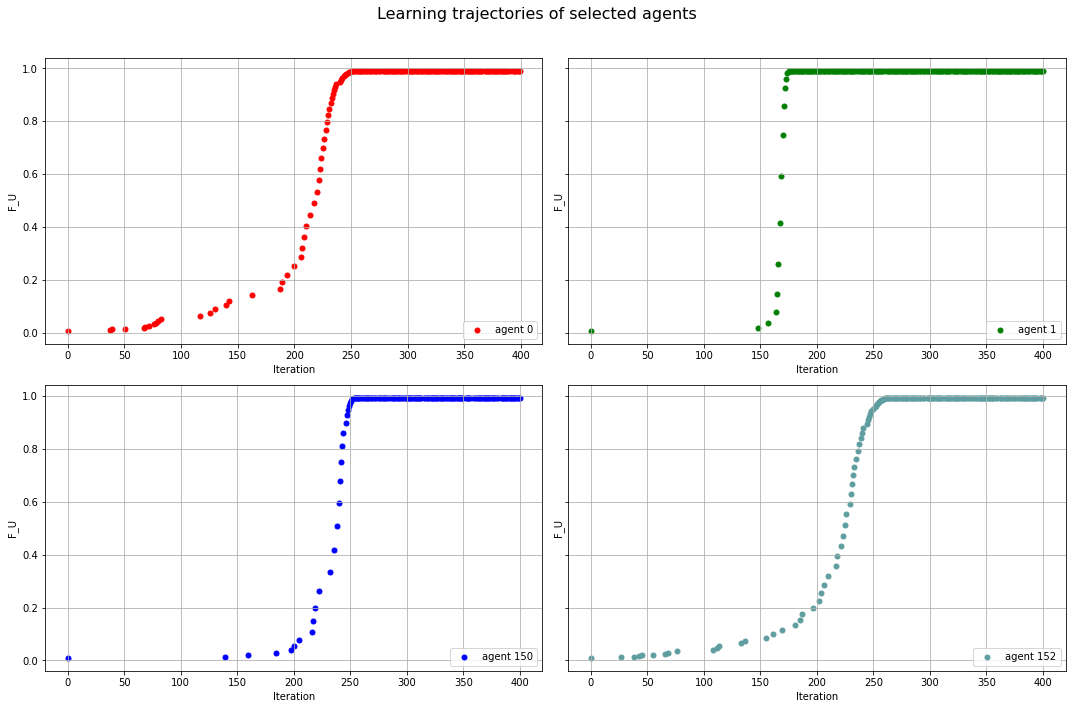

In [69]:
# 400 iterations
ns = [0, 1, 150, 152]
colors = ['red', 'green', 'blue', 'cadetblue']

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # Flatten 2x2 array to 1D for easy looping

for ax, n, c in zip(axs, ns, colors):
    xs = []
    U_F = []
    for i, val in enumerate(res_400_0["Skotniki"]["df_fus"].iloc[n].to_list()):
        if not np.isnan(val):
            xs.append(i)
            U_F.append(val)
    ax.scatter(xs, U_F, color=c, label=f"agent {n}", s=25)
    ax.set_ylabel("F_U")
    ax.set_xlabel("Iteration")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("Learning trajectories of selected agents", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# SET UP shared_discount = 0.3 (CONST)
params.learning_d = 1.5 # learning rate
params.mu = 5
params.min_U = 0.01
params.shared_discount = 0.3

res_400_03 = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=400, ASC=5.8, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.22264740562552285
iteration  1  for Skotniki
sum_demand sample 33
iteration  2  for Skotniki
sum_demand sample 11
iteration  3  for Skotniki
sum_demand sample 5
iteration  4  for Skotniki
sum_demand sample 5
iteration  5  for Skotniki
sum_demand sample 7
iteration  6  for Skotniki
sum_demand sample 5
iteration  7  for Skotniki
sum_demand sample 4
iteration  8  for Skotniki
sum_demand sample 5
iteration  9  for Skotniki
sum_demand sample 3
iteration  10  for Skotniki
sum_demand sample 4
iteration  11  for Skotniki
sum_demand sample 6
iteration  12  for Skotniki
sum_demand sample 3
iteration  13  for Skotniki
sum_demand sample 5
iteration  14  for Skotniki
sum_demand sample 6
iteration  15  for Skotniki
sum_demand sample 5
iteration  16  for Skotniki
sum_demand sample 4
iteration  17  for Skotniki
sum_demand sample 2
iteration  18  for Skotniki
sum_demand sample 5
iteration  19  for Skotniki
sum_demand sample 8
iteration  20  

In [ ]:
# SET UP shared_discount = 0.0 if i < 50 else 0.3
params.learning_d = 1.5 # learning rate
params.mu = 5
params.min_U = 0.01

res = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=400, ASC=5.8, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.031823461463035344
iteration  1  for Skotniki
sum_demand sample 5
iteration  2  for Skotniki
sum_demand sample 5
iteration  3  for Skotniki
sum_demand sample 4
iteration  4  for Skotniki
sum_demand sample 7
iteration  5  for Skotniki
sum_demand sample 3
iteration  6  for Skotniki
sum_demand sample 1
iteration  7  for Skotniki
sum_demand sample 3
iteration  8  for Skotniki
sum_demand sample 6
iteration  9  for Skotniki
sum_demand sample 2
iteration  10  for Skotniki
sum_demand sample 8
iteration  11  for Skotniki
sum_demand sample 3
iteration  12  for Skotniki
sum_demand sample 1
iteration  13  for Skotniki
sum_demand sample 4
iteration  14  for Skotniki
sum_demand sample 2
iteration  15  for Skotniki
sum_demand sample 3
iteration  16  for Skotniki
sum_demand sample 1
iteration  17  for Skotniki
sum_demand sample 2
iteration  18  for Skotniki
sum_demand sample 2
iteration  19  for Skotniki
sum_demand sample 7
iteration  20  f

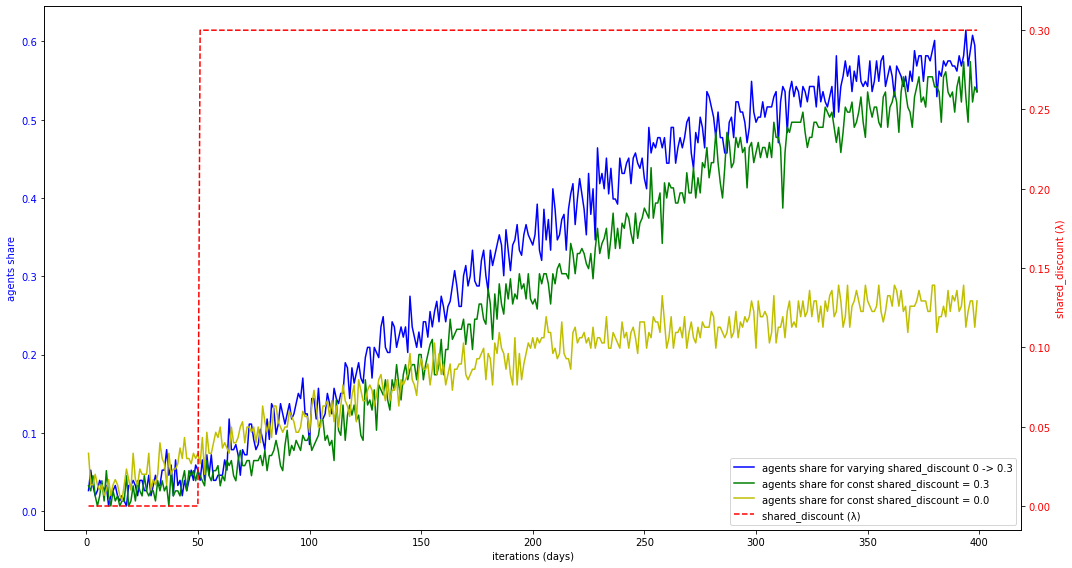

In [65]:
a_sh_0 = [i / res_400_0["Skotniki"]['sum_res'].shape[0] for i in [s_res.shape[0] for s_res in res_400_0["Skotniki"]["s_res"]]]
a_sh_3 = [i / res_400_03["Skotniki"]['sum_res'].shape[0] for i in [s_res.shape[0] for s_res in res_400_03["Skotniki"]["s_res"]]]
a_sh_0_3 = [i / res["Skotniki"]['sum_res'].shape[0] for i in [s_res.shape[0] for s_res in res["Skotniki"]["s_res"]]]

xs = range(1, len(a_sh_0))
ys = [0.3 if i > 50 else 0.0 for i in xs]

fig, ax1 = plt.subplots(figsize=(15, 8))

# agent share
ax1.plot(xs, a_sh_0[1:], 'b-', label='agents share for varying shared_discount 0 -> 0.3')
ax1.set_xlabel('iterations (days)')
ax1.set_ylabel('agents share', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax1.plot(xs, a_sh_0_3[1:], 'g-', label='agents share for const shared_discount = 0.3')
ax1.plot(xs, a_sh_3[1:], 'y-', label='agents share for const shared_discount = 0.0')

# shared discount as a step function
ax2 = ax1.twinx()
ax2.plot(xs, ys, 'r--', label='shared_discount (λ)')
ax2.set_ylabel('shared_discount (λ)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='lower right')

# plt.title('Feeder Adoption and Shared Discount Over Iterations')
# plt.grid(True)
plt.tight_layout()
plt.show()

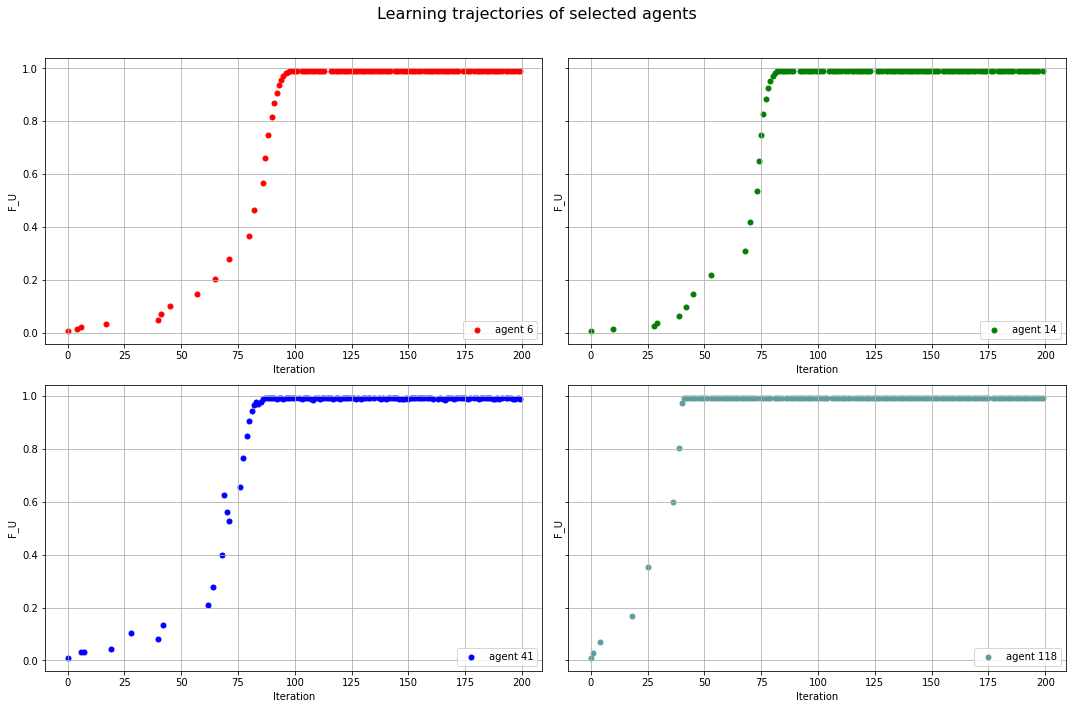

In [ ]:
# 200 iterations
ns = [6, 14, 41, 118]
colors = ['red', 'green', 'blue', 'cadetblue']

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # Flatten 2x2 array to 1D for easy looping

for ax, n, c in zip(axs, ns, colors):
    xs = []
    U_F = []
    for i, val in enumerate(res["Skotniki"]["df_fus"].iloc[n].to_list()):
        if not np.isnan(val):
            xs.append(i)
            U_F.append(val)
    ax.scatter(xs, U_F, color=c, label=f"agent {n}", s=25)
    ax.set_ylabel("F_U")
    ax.set_xlabel("Iteration")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("Learning trajectories of selected agents", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [35]:
# SET UP (shared_discount = 0.3, initial ttrav = dist / avg_speed:
params.learning_d = 1.5 # learning rate
params.mu = 5
params.min_U = 0.01
params.shared_discount = 0.3

res_03 = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=200, ASC=5.8, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.023640672090814562
iteration  1  for Skotniki
sum_demand sample 4
iteration  2  for Skotniki
sum_demand sample 3
iteration  3  for Skotniki
sum_demand sample 4
iteration  4  for Skotniki
sum_demand sample 5
iteration  5  for Skotniki
sum_demand sample 3
iteration  6  for Skotniki
sum_demand sample 1
iteration  7  for Skotniki
sum_demand sample 3
iteration  8  for Skotniki
sum_demand sample 0
iteration  9  for Skotniki
sum_demand sample 2
iteration  10  for Skotniki
sum_demand sample 4
iteration  11  for Skotniki
sum_demand sample 4
iteration  12  for Skotniki
sum_demand sample 4
iteration  13  for Skotniki
sum_demand sample 4
iteration  14  for Skotniki
sum_demand sample 3
iteration  15  for Skotniki
sum_demand sample 3
iteration  16  for Skotniki
sum_demand sample 3
iteration  17  for Skotniki
sum_demand sample 8
iteration  18  for Skotniki
sum_demand sample 2
iteration  19  for Skotniki
sum_demand sample 6
iteration  20  f

In [39]:
# SET UP (shared_discount = 0, initial ttrav = dist / avg_speed:
params.learning_d = 1.5 # learning rate
params.mu = 5
params.min_U = 0.01
params.shared_discount = 0

res_0 = simulate_learning(pd.DataFrame([gdf_areas.iloc[1]]), df_demo, gdf_centroid, od, od_probs, hubs, inData, params, OTP_API, 
                 degree=6, N=1, max_iter=200, ASC=5.8, results_period=0)

1 run simulations for area Skotniki : sample size  155
F_P  0.014679643443835858
iteration  1  for Skotniki
sum_demand sample 0
iteration  2  for Skotniki
sum_demand sample 1
iteration  3  for Skotniki
sum_demand sample 2
iteration  4  for Skotniki
sum_demand sample 1
iteration  5  for Skotniki
sum_demand sample 2
iteration  6  for Skotniki
sum_demand sample 4
iteration  7  for Skotniki
sum_demand sample 1
iteration  8  for Skotniki
sum_demand sample 2
iteration  9  for Skotniki
sum_demand sample 3
iteration  10  for Skotniki
sum_demand sample 4
iteration  11  for Skotniki
sum_demand sample 4
iteration  12  for Skotniki
sum_demand sample 2
iteration  13  for Skotniki
sum_demand sample 2
iteration  14  for Skotniki
sum_demand sample 3
iteration  15  for Skotniki
sum_demand sample 3
iteration  16  for Skotniki
sum_demand sample 0
iteration  17  for Skotniki
sum_demand sample 4
iteration  18  for Skotniki
sum_demand sample 3
iteration  19  for Skotniki
sum_demand sample 2
iteration  20  f

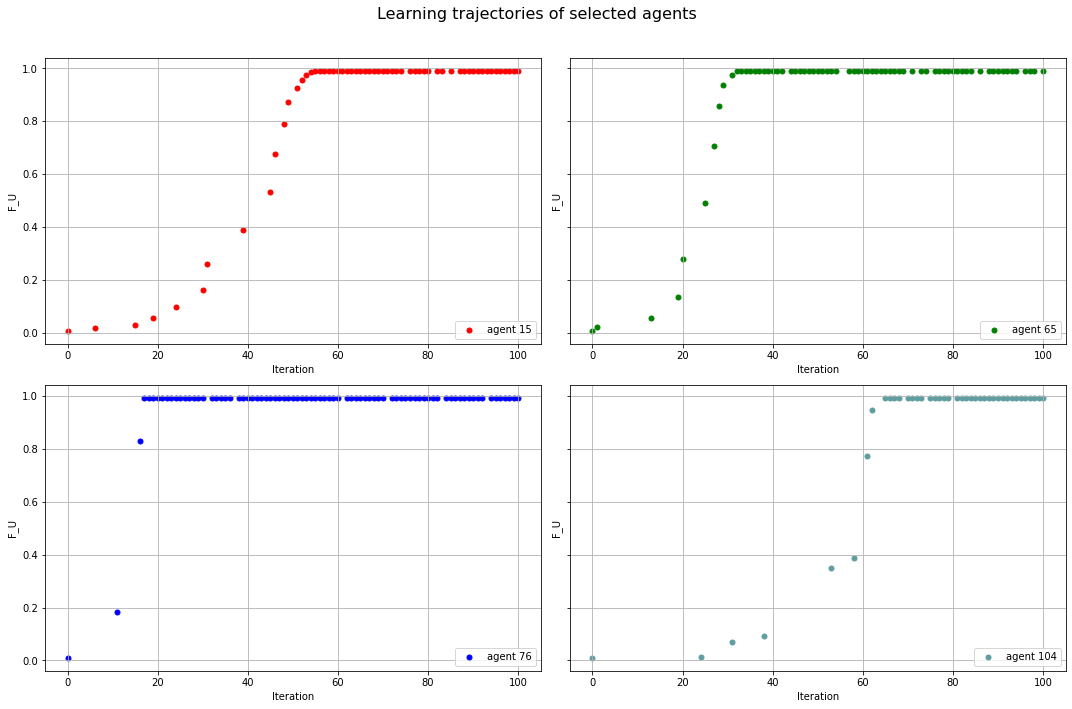

In [34]:
ns = [15, 65, 76, 104]
colors = ['red', 'green', 'blue', 'cadetblue']

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # Flatten 2x2 array to 1D for easy looping

for ax, n, c in zip(axs, ns, colors):
    xs = []
    U_F = []
    for i, val in enumerate(results_1["Skotniki"]["df_fus"].iloc[n].to_list()):
        if not np.isnan(val):
            xs.append(i)
            U_F.append(val)
    ax.scatter(xs, U_F, color=c, label=f"agent {n}", s=25)
    ax.set_ylabel("F_U")
    ax.set_xlabel("Iteration")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("Learning trajectories of selected agents", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

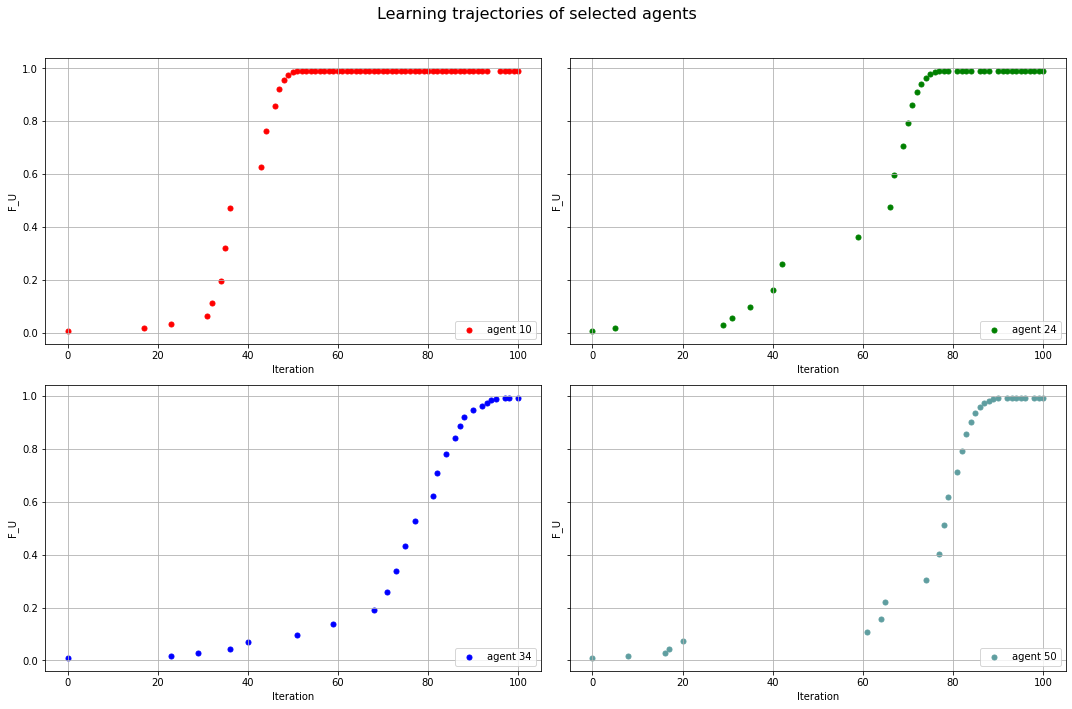

In [44]:
# 10, 34, 50, 88
ns = [10, 24, 34, 50]
colors = ['red', 'green', 'blue', 'cadetblue']

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
axs = axs.flatten()  # Flatten 2x2 array to 1D for easy looping

for ax, n, c in zip(axs, ns, colors):
    xs = []
    U_F = []
    for i, val in enumerate(results_2["Skotniki"]["df_fus"].iloc[n].to_list()):
        if not np.isnan(val):
            xs.append(i)
            U_F.append(val)
    ax.scatter(xs, U_F, color=c, label=f"agent {n}", s=25)
    ax.set_ylabel("F_U")
    ax.set_xlabel("Iteration")
    ax.legend(loc="lower right")
    ax.grid(True)

fig.suptitle("Learning trajectories of selected agents", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()